<a href="https://colab.research.google.com/github/salahbenlabidi-cmyk/AgriCure-DZ./blob/main/Copie_de_Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

الرجاء اختيار صورة النبتة المصابة من هاتفك:


Saving IMG_20260414_134455.jpg to IMG_20260414_134455.jpg
تم رفع الملف: "IMG_20260414_134455.jpg" بنجاح


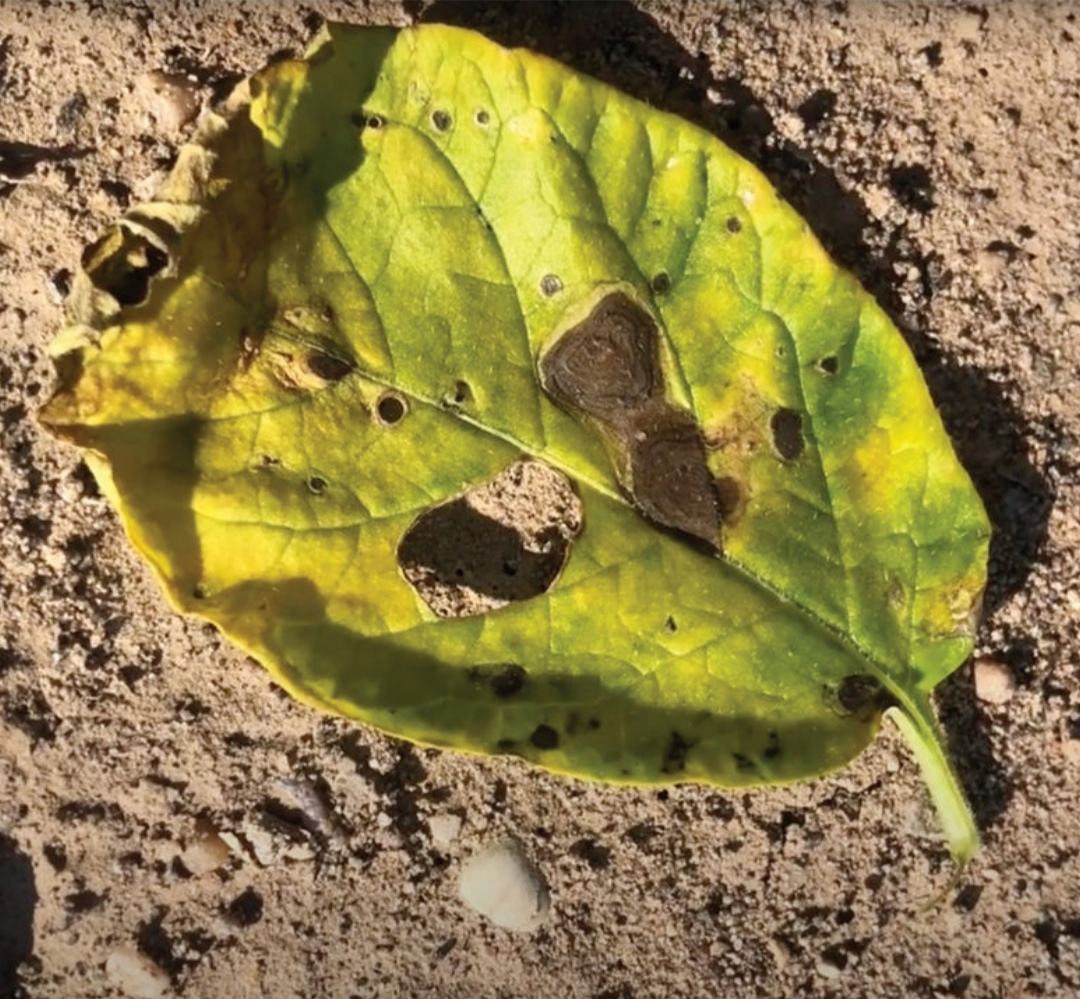


جاري تحليل الصورة... (تأكد من تحميل ملفات النموذج .h5 أو .tflite)


In [4]:
from google.colab import files
from IPython.display import Image, display

# خطوة 1: رفع صورة النبتة المريضة من جهازك
print("الرجاء اختيار صورة النبتة المصابة من هاتفك:")
uploaded = files.upload()

# خطوة 2: عرض الصورة للتأكد
for fn in uploaded.keys():
  print('تم رفع الملف: "{name}" بنجاح'.format(name=fn))
  display(Image(fn, width=300))

# ملاحظة: هنا يجب استدعاء نموذج AgriCure-DZ للتشخيص
print("\nجاري تحليل الصورة... (تأكد من تحميل ملفات النموذج .h5 أو .tflite)")

In [8]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

# 1. تحميل النموذج (تأكد من رفع ملف باسم model.h5 في القائمة الجانبية)
try:
    model = tf.keras.models.load_model('model.h5')
    print("✅ تم تحميل نموذج AgriCure بنجاح!")

    # 2. تجهيز الصورة التي رفعتها للتحليل
    img_path = list(uploaded.keys())[-1]
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0) / 255.0

    # 3. تشخيص المرض
    predictions = model.predict(x)

    # قائمة الأمراض (عدلها حسب مشروعك)
    classes = ['نبتة سليمة', 'تبقع أوراق ألتيرناري', 'لفحة بكتيرية', 'مرض الصدأ']
    result = classes[np.argmax(predictions)]

    print(f"\n🔬 التشخيص المقترح: {result}")
    print(f"📊 نسبة التأكد: {np.max(predictions)*100:.2f}%")

except Exception as e:
    print(f"❌ خطأ: يرجى رفع ملف 'model.h5' أولاً في أيقونة المجلد على اليسار.")

❌ خطأ: يرجى رفع ملف 'model.h5' أولاً في أيقونة المجلد على اليسار.
